<a href="https://colab.research.google.com/github/vikrampal12345/LangGraph/blob/main/Condition_workflow_withoutLLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
import os
from pydantic import BaseModel, Field

In [39]:
class EquationState(TypedDict):
  a : int
  b : int
  c : int

  equation : str
  discrim : float
  result : str

In [40]:
def show_equation(state: EquationState):
  equation = f'{state["a"]}X2{state["b"]}X{state["c"]}'
  return {'equation': equation}

In [41]:
def calculate_discrim(state: EquationState):
  discrim = state["b"]**2 - (4*state["a"]*state["c"])
  return {'discrim' : discrim}

In [42]:
def real_roots(state: EquationState):

  root1 = (-state["b"] + state["discrim"]**0.5)/(2*state["a"])
  root2 = (-state["b"] - state["discrim"]**0.5)/(2*state["a"])

  result = f"The roots are {root1} and {root2}"

  return {"result" : result}

In [43]:
def repeated_roots(state: EquationState):

  root = (-state["b"])/(2*state["a"])

  result = f"only repeating root is {root}"

  return {'result': result}



In [44]:
def no_real_roots(state: EquationState):
  result = f"No real root"

  return {'result': result}


In [45]:
def check_condition(state: EquationState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
  if state['discrim'] > 0:
    return "real_roots"
  elif state["discrim"] == 0:
    return "repeated_roots"
  else:
    return "no_real_roots"

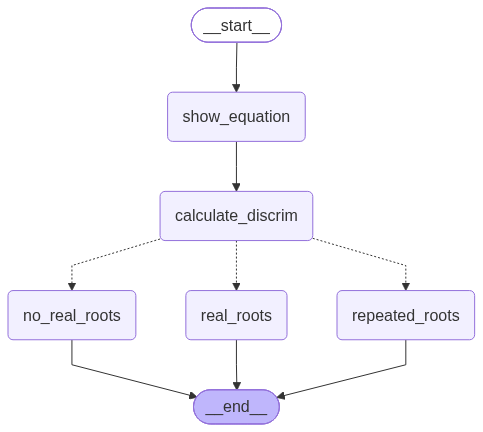

In [46]:
graph = StateGraph(EquationState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discrim', calculate_discrim)

graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discrim")
graph.add_conditional_edges("calculate_discrim", check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)


graph.compile()

In [47]:
workflow = graph.compile()

In [52]:
initial_state = {
    'a' : 2,
    'b' : +2,
    'c' : 2
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 2,
 'c': 2,
 'equation': '2X22X2',
 'discrim': -12,
 'result': 'No real root'}